## Load modules

In [1]:
!pip install --no-index seaborn

Looking in links: /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/x86-64-v3, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/gentoo2023/generic, /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic
Processing /cvmfs/soft.computecanada.ca/custom/python/wheelhouse/generic/seaborn-0.13.2+computecanada-py3-none-any.whl


Close the notebook (using the open tabs menu) and restart

## Import packages 

In [1]:
import numpy as np
import pandas as pd
import math as math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import subprocess
import os
import scipy.stats as stats
from collections import Counter

import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

Import your sample datasheet. If you have already run part of the notebook, some additional columns might be there.

In [3]:
sample_datasheet = pd.read_csv('./time_course_samples.csv', sep=',', index_col=0)
sample_datasheet

,strain,timepoint,condition,replicate,fastq_path,raw_reads
sample,,,,,,
1,WT,0,T0,T0,data/1_S88_L001,540134
2,WT,T1,NoATC,1,data/2-ATC-2_S29_L001,589307
3,WT,T1,NoATC,2,data/3-ATC-2_S30_L001,609273
4,WT,T1,NoATC,3,data/4-ATC-2_S31_L001,527666
5,WT,T1,ATC,1,data/5-ATC-2_S34_L001,486977
6,WT,T1,ATC,2,data/6-ATC-2_S35_L001,650280
7,WT,T1,ATC,3,data/7-ATC-2_S36_L001,408841
8,WT,T2,NoATC,1,data/8-ATC-2_S38_L001,526937
9,WT,T2,NoATC,2,data/9-ATC-2_S39_L001,462842


## Get the number of raw reads for each file (run once then skip afterwards)

In [4]:
raw_read_count_dict = {}
# empty dictionnary to hold the library:n_reads info

for sample in sample_datasheet.index:
    # loop through samples in datasheet
    
    R1_fastq_path = sample_datasheet.at[sample,'fastq_path']+'_R1_001.fastq.gz'
    # path to the fasq file 
    command = 'zgrep -o \'@M\' '+R1_fastq_path+' | wc -l'
    # command to count number of fastq headers in the file, header guide from: https://www.biostars.org/p/198143/#198150 
    # @HWI-Mxxxx or @Mxxxx - MiSeq
    # @HWUSI - GAIIx
    # @HWI-Dxxxx - HiSeq 2000/2500
    # @Kxxxx - HiSeq 3000(?)/4000
    # @Nxxxx - NextSeq 500/550
    # @Axxxxx - NovaSeq
    # @Vxxxxx = NextSeq 2000
    # Edit (08/2022)
    # @AAxxxxx - NextSeq 2000 P1/P2/P3
    # @Hxxxxxx - NovaSeq S1/S2/S4
    
    output  = subprocess.check_output('zgrep -o \'@M\' '+R1_fastq_path+' | wc -l', shell=True, text=True)
    raw_read_count_dict[sample] = int(output.strip('\n'))
    # run the command and store the output
    
sample_datasheet['raw_reads'] = pd.Series(raw_read_count_dict)
    
sample_datasheet.to_csv('./time_course_samples.csv', sep=',')
    
# this step takes ~18s to complete for a 3M read dataset, so expect run time to scale accordingly. 
# To avoid redoing it, we save the dataframe after finishing this step -> 10M reads/min

In [5]:
sum(raw_read_count_dict.values())
# total number of reads sequenced

11223311

Text(0, 0.5, 'Number of reads')

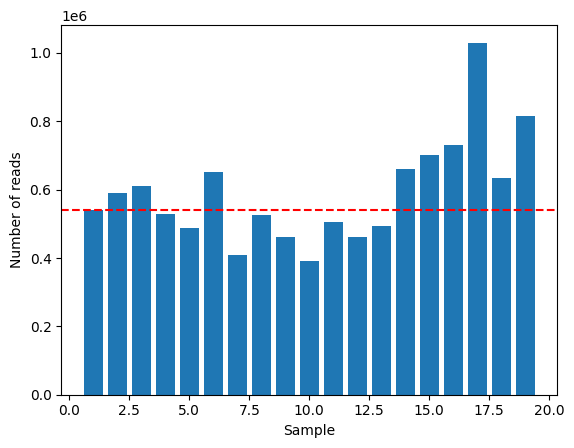

In [6]:
plt.bar([x for x in sample_datasheet.index], [sample_datasheet.at[x, 'raw_reads'] for x in sample_datasheet.index])
plt.axhline(np.median([sample_datasheet.at[x, 'raw_reads'] for x in sample_datasheet.index]), color='r', linestyle='--')
plt.xlabel('Sample')
plt.ylabel('Number of reads')

## Prepare directories

In [8]:
list_dir = os.listdir()

if 'logs' not in list_dir:
    os.mkdir('logs')
if 'fastqc_outputs' not in list_dir:
    os.mkdir('fastqc_outputs')
if 'pear_output' not in list_dir:
    os.mkdir('pear_output')
if 'vsearch_trim' not in list_dir:
    os.mkdir('vsearch_trim')
if 'vsearch_aggregate' not in list_dir:
    os.mkdir('vsearch_aggregate')
if 'barcode_counts' not in list_dir:
    os.mkdir('barcode_counts')
# If they are not already present, create directories for intermediate analysis files

## Write bash script to run FastQC on samples (QC for sequencer output)
Change the time as a function of the number of reads. A 14 * 0.85M test dataset took about 33s, so about 1.4M reads/min. Consider increasing the runtime if you have > 85M reads per sample.

In [7]:
n_files = len(sample_datasheet.index)*2
print(n_files)

with open('./run_fastqc.sh', 'w') as dest:
    
    

    dest.write('#!/bin/bash'+'\n')                         # bash header
    dest.write('#SBATCH --account=def-rshap'+'\n')         # compute canada PI account
    dest.write('#SBATCH --cpus-per-task='+str(n_files+1)+'\n')          # number of cpus for the job
    dest.write('#SBATCH --mem='+str(math.ceil(((n_files+1)*0.5)))+'G\n')                    # RAM for the job
    dest.write('#SBATCH --time=0-01:00'+'\n')              # time limit
    dest.write('#SBATCH --output=logs/slurm-%j.out'+'\n')  # directory to store logs limit
    dest.write('\n'+'\n')
    
    dest.write('module load fastqc'+'\n')
    # load the fastqc module
    
    fastqc_command = 'fastqc --outdir fastqc_outputs -t '+str(n_files)+ ' --extract --delete ./data/*.fastq.gz'
    dest.write(fastqc_command)
   

38


## Write bash script
Change the time as a function of the number of reads. A 3M test dataset took about 5 mins and 3 GB of RAM, so about 0.6M reads/million reads and 1 GB RAM per million reads.

In [8]:
with open('./process_barcodes.sh', 'w') as dest:
    dest.write('#!/bin/bash'+'\n')                         # bash header
    dest.write('#SBATCH --account=def-rshap'+'\n')         # compute canada PI account
    dest.write('#SBATCH --cpus-per-task=16'+'\n')          # number of cpus for the job
    dest.write('#SBATCH --mem=5G'+'\n')                    # RAM for the job
    dest.write('#SBATCH --time=0-02:00'+'\n')              # time limit
    dest.write('#SBATCH --output=logs/slurm-%j.out'+'\n')  # directory to store logs limit
    dest.write('\n'+'\n')
    
    dest.write('module load StdEnv/2020'+'\n') # load software modules 
    
    dest.write('module load pear'+'\n')
    dest.write('module load vsearch'+'\n')
    
    for sample in sample_datasheet.index:
        dest.write('date'+'\n')
        fastq_path = sample_datasheet.at[sample, 'fastq_path']
        fastq_R1 = fastq_path +'_R1_001.fastq.gz'
        fastq_R2 = fastq_path +'_R2_001.fastq.gz'
        pear_out = './pear_output/'+str(sample)
        
        pear_command = 'pear -f '+fastq_R1+' -r '+fastq_R2+' -o '+pear_out+' -j 16 -u 0.01 -q 20 -m 308 -n 290'+'\n'
        dest.write(pear_command)
        
        assembled_reads = './pear_output/'+str(sample)+'.assembled.fastq'
        dest.write('date'+'\n')
        
        filter_out = './vsearch_trim/'+str(sample)+'_trimmed.fastq'
        filter_rc = './vsearch_trim/'+str(sample)+'_trimmed_rc.fastq'
        
        filter_command = 'vsearch --fastx_filter '+assembled_reads+' --fastq_stripleft 134 --fastq_stripright 79 --fastaout '+filter_out+'\n'
        rc_command = 'vsearch --fastx_revcomp '+filter_out+' --fastaout '+filter_rc+'\n'
        
        dest.write(filter_command)
        dest.write(rc_command)
        
        dest.write('date'+'\n')
        
        aggregate_fasta = './vsearch_aggregate/'+str(sample)+'_aggregate.fasta'
        aggregate_command = 'vsearch --derep_fulllength '+filter_rc+' --relabel seq --output '+aggregate_fasta+' --sizeout'+'\n'
        
        dest.write(aggregate_command)
        
    dest.write('date'+'\n')
        
        
        



In [9]:
assembled_read_count = {}

for sample in sample_datasheet.index:
    assembled_reads = './pear_output/'+str(sample)+'.assembled.fastq'
    command = 'grep -o \'@M\' '+assembled_reads+' | wc -l'
    # command to count number of fastq headers in the file, header guide from: https://www.biostars.org/p/198143/#198150 
    # @HWI-Mxxxx or @Mxxxx - MiSeq
    # @HWUSI - GAIIx
    # @HWI-Dxxxx - HiSeq 2000/2500
    # @Kxxxx - HiSeq 3000(?)/4000
    # @Nxxxx - NextSeq 500/550
    # @Axxxxx - NovaSeq
    # @Vxxxxx = NextSeq 2000
    # Edit (08/2022)
    # @AAxxxxx - NextSeq 2000 P1/P2/P3
    # @Hxxxxxx - NovaSeq S1/S2/S4
    
    output  = subprocess.check_output(command, shell=True, text=True)
    assembled_read_count[sample] = int(output.strip('\n'))
    
sample_datasheet['assembled_reads'] = pd.Series(assembled_read_count)
    
sample_datasheet.to_csv('./sample_datasheet_updated.csv', sep=',')

In [10]:
sample_datasheet

,strain,timepoint,condition,replicate,fastq_path,raw_reads,assembled_reads
sample,,,,,,,
1,WT,0,T0,T0,data/1_S88_L001,540134,505438
2,WT,T1,NoATC,1,data/2-ATC-2_S29_L001,589307,566878
3,WT,T1,NoATC,2,data/3-ATC-2_S30_L001,609273,583479
4,WT,T1,NoATC,3,data/4-ATC-2_S31_L001,527666,497360
5,WT,T1,ATC,1,data/5-ATC-2_S34_L001,486977,473002
6,WT,T1,ATC,2,data/6-ATC-2_S35_L001,650280,635141
7,WT,T1,ATC,3,data/7-ATC-2_S36_L001,408841,392602
8,WT,T2,NoATC,1,data/8-ATC-2_S38_L001,526937,514756
9,WT,T2,NoATC,2,data/9-ATC-2_S39_L001,462842,448271


Text(0, 0.5, 'Number of merged reads')

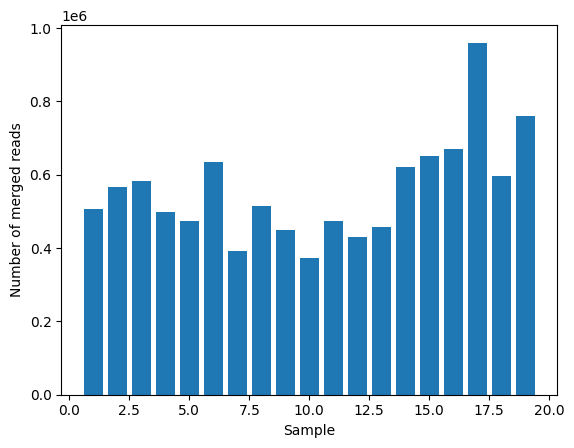

In [11]:
plt.bar([x for x in sample_datasheet.index], [sample_datasheet.at[x, 'assembled_reads'] for x in sample_datasheet.index])
plt.xlabel('Sample')
plt.ylabel('Number of merged reads')

In [12]:
merge_stats = stats.linregress(sample_datasheet.raw_reads, sample_datasheet.assembled_reads)


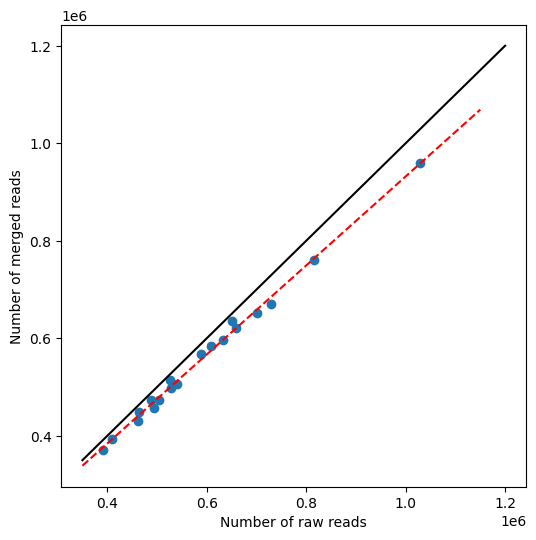

In [13]:
plt.figure(figsize=(6,6))
plt.scatter(sample_datasheet.raw_reads, sample_datasheet.assembled_reads)

plt.plot([350000, 1200000], [350000, 1200000], '-k')

plt.xlabel('Number of raw reads')
plt.ylabel('Number of merged reads')

plt.plot([x for x in range(350000, 1200000, 50000)], [(x*merge_stats[0])+merge_stats[1] for x in range(350000, 1200000, 50000)], 'r--')

## Import sgRNA/barcode dataframe

In [17]:
sgRNA_df = pd.read_csv('./sgrna_annot.csv', index_col=0)
sgRNA_df

,Gene,alias,SgRNA,Barcode,control,strand,atg_dist,B_mismatch,dist_TSS,abs_TSS_dist,GC_content
0,C1_00220W,PHR2,1,TTGGCTTTCCTCCCCTTAAC,0,+,112.0,no,-9.0,9.0,50.000000
1,C1_00220W,PHR2,2,TCCTTGAATTTCTTGGTAGA,0,-,45.0,no,58.0,58.0,35.000000
2,C1_00220W,PHR2,3,CGATGATTCCTTGAATTTCT,0,-,38.0,no,65.0,65.0,35.000000
3,C1_00220W,PHR2,4,CAACAGTAGCAGAATTGTAC,0,+,288.0,no,-185.0,185.0,40.000000
4,C1_00400W,SVF1,5,TTAATGTCGCTTAGTGATGG,0,-,177.0,no,-89.0,89.0,40.000000
...,...,...,...,...,...,...,...,...,...,...,...
548,R-sgRNA 27,NaN,551,GGTATCGTCGTGTCTCATTA,1,NaN,NaN,no,NaN,NaN,45.000000
549,R-sgRNA 28,NaN,552,CGCGTCCAGGTTCTTCTGGA,1,NaN,NaN,no,NaN,NaN,60.000000
550,R-sgRNA 29,NaN,553,TGTTGGATCGTCCCTAGGAA,1,NaN,NaN,no,NaN,NaN,50.000000
551,R-sgRNA 30,NaN,554,TCTGACGATCTGTTGTGAGA,1,NaN,NaN,no,NaN,NaN,45.000000


In [18]:
non_count_cols = list(sgRNA_df.columns)
# list of columns present in the starting dataframe

In [19]:
def get_dict_of_seq(fasta_file):
    """ function that converts a fasta file to a dictionnary of sequences
    fasta_file: the input fasta file
    """
    
    file_fasta_dict = {}
    # output dict of imported seqs
    
    with open(fasta_file, 'r') as fasta:    
        for line in fasta:
            # loops through the file

            if line.startswith('>') == True:
                seq_info = line.strip('>').strip('\n').split('\t')[0]
                file_fasta_dict[seq_info] = ''
                # checks if seq header

            else:
                file_fasta_dict[seq_info] += line.strip('\n')
                # If not, append nt to current seq
                
    return file_fasta_dict

## Count sgRNAs using perfect match, with a 8nt anchor

In [20]:
def count_barcodes_perfect_match(fasta_seq_dict, barcode_dict):
    # from a dictionnary of aggregate fasta entry and the sgRNA table, count the number of reads associated
    # with each guide, only counting perfect sequence matches to the sgRNA with an 8 nt "anchor" in 3' and 5'
    # to prevent +1/-1 shifted sgRNA from contaminating one another
       
    sample_sgRNA_counter = Counter()
    # empty counter to store sgRNA count values
    
    for key in list(fasta_seq_dict.keys()):
        # iterate trough aggregate sequences
        
        seq_count = int(key.split(';size=')[1])
        # get sequence counts for the fasta entry
        
        n_match = 0
        barcode_ids = []
        # containers for debugging
        
        for barcode in list(barcode_dict.keys()):
            # iterate through sgRNA sequences
            
            if "AATTTCGA"+barcode+"GTTTTAGA" in fasta_seq_dict[key]:
                # add 8nt in 5' and 3' to anchor the sgRNA
                n_match+=1
                barcode_ids.append(barcode)
                # increment match counter and match list for debugging
                if n_match > 1:
                    print(key, n_match, barcode_ids)
                    # print a warning if a sequence matches multiple sgRNAs
                    
                sample_sgRNA_counter[barcode_dict[barcode]] +=seq_count
                # add sgRNA count to Counter
                
            elif barcode == 'TGAAGAGCCATTAATGCTCTTCC':
                if 'GGAAGAGCATTAATGGCTCTTCA' in fasta_seq_dict[key]:
                    n_match+=1
                    barcode_ids.append(barcode)
                    # increment match counter and match list for debugging
                    if n_match > 1:
                        print(key, n_match, barcode_ids)
                        # print a warning if a sequence matches multiple sgRNAs
                    
                    sample_sgRNA_counter[barcode_dict[barcode]] +=seq_count
                    # add sgRNA count to Counter
                    
        if n_match>1:
            print(key)
                    
        #if seq_count>50 and n_match==0:
        #    print(key, fasta_seq_dict[key])
                    
    return sample_sgRNA_counter

In [21]:
3/0.66

4.545454545454545

As it is, this takes ~40s for 3M reads, so about 4.5M reads per minute. Can be left to run on its own for a while if you have a very large dataset.

In [22]:
usable_reads_dict = {}

barcode_dict = {}

for sgRNA in sgRNA_df.index:
    barcode = sgRNA_df.at[sgRNA, 'Barcode']
    barcode_dict[barcode] = sgRNA

for sample in sample_datasheet.index:
    aggregate_fasta = './vsearch_aggregate/'+str(sample)+'_aggregate.fasta'
    fasta_dict = get_dict_of_seq(aggregate_fasta)
    
    
    
    
    sgRNA_counter = count_barcodes_perfect_match(fasta_dict, barcode_dict)
    usable_reads_dict[sample] = sum(sgRNA_counter.values())
    
    col_name = sample_datasheet.at[sample, 'strain']+'_'
    col_name += str(sample_datasheet.at[sample, 'timepoint'])+'_'
    col_name += str(sample_datasheet.at[sample, 'condition'])+'_'
    col_name += str(sample_datasheet.at[sample, 'replicate'])
    
    sgRNA_df[col_name] = pd.Series(sgRNA_counter)
    

    
#usable_reads_dict

In [22]:
raw_read_count_dict

{1: 540134,
 2: 589307,
 3: 609273,
 4: 527666,
 5: 486977,
 6: 650280,
 7: 408841,
 8: 526937,
 9: 462842,
 10: 390809,
 11: 504087,
 12: 462173,
 13: 494292,
 14: 659729,
 15: 701537,
 16: 729434,
 17: 1029739,
 18: 633555,
 19: 815699}

In [23]:
usable_reads_dict

{1: 460167,
 2: 430236,
 3: 434337,
 4: 362378,
 5: 349422,
 6: 466224,
 7: 292411,
 8: 374016,
 9: 330517,
 10: 274021,
 11: 339063,
 12: 295748,
 13: 340055,
 14: 567889,
 15: 594783,
 16: 610994,
 17: 877464,
 18: 541053,
 19: 693737}

In [24]:
pd.Series(sgRNA_counter)

540    13460
545    12808
440    12000
483    12091
521    10951
       ...  
225        6
205        6
168        5
16         5
466        2
Length: 529, dtype: int64

In [25]:
sample_datasheet['usable_reads'] = pd.Series(usable_reads_dict)
usable_stats = stats.linregress(sample_datasheet.raw_reads, sample_datasheet.usable_reads)
print(usable_stats)

LinregressResult(slope=1.0084186222104001, intercept=-141225.30606625415, rvalue=0.981145114063889, pvalue=1.421045663889146e-13, stderr=0.04817849723209716, intercept_stderr=29366.371206650027)


(0.0, 1200000.0)

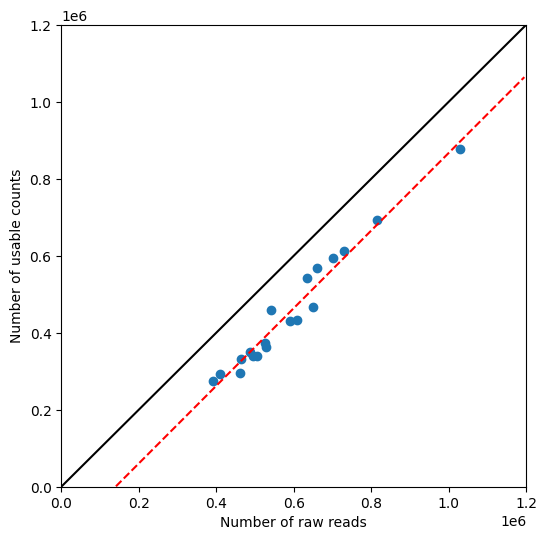

In [26]:
plt.figure(figsize=(6,6))
plt.scatter(sample_datasheet.raw_reads, sample_datasheet.usable_reads)

plt.plot([0,1200000], [0,1200000], '-k')

plt.xlabel('Number of raw reads')
plt.ylabel('Number of usable counts')

plt.plot([x for x in range(0,1200000, 5000)], [(x*usable_stats[0])+usable_stats[1] for x in range(0,1200000, 5000)], 'r--')

plt.xlim(0,1200000)
plt.ylim(0,1200000)

Text(0, 0.5, 'Number of usable reads')

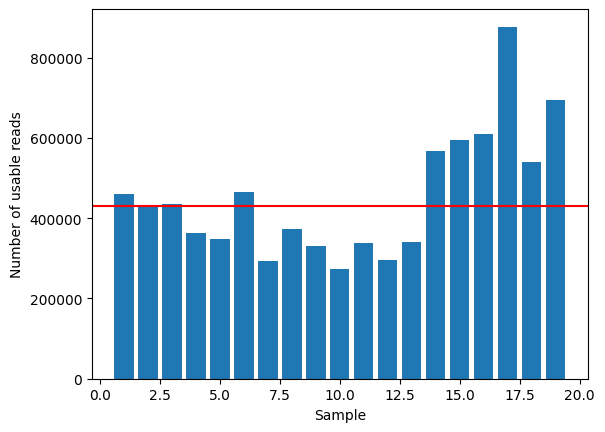

In [27]:
plt.bar([x for x in sample_datasheet.index], [sample_datasheet.at[x, 'usable_reads'] for x in sample_datasheet.index])
plt.axhline(sample_datasheet['usable_reads'].median(), color='red')
plt.xlabel('Sample')
plt.ylabel('Number of usable reads')

In [28]:
sgRNA_df.to_csv('./sgRNAs_annot_wcounts_screen_1.csv', sep=',')